In [1]:
import numpy as np
from numpy import random
import numba as nb
import matplotlib.pyplot as plt

In [2]:
L_list = [25,50,100,200]
n_min = [800,1600,4200,10**4]
n_max = [n+10**4 for n in n_min]
print(n_min,n_max)

[800, 1600, 4200, 10000] [10800, 11600, 14200, 20000]


In [3]:
# does not work with numba
def topple(array,count):
     mask = np.copy(array)>1
     N = np.shape(array)[0]
     frustration = np.sum(mask)
     count += frustration
     # create new array with update values to be added to array
     update_array = np.zeros_like(array)
     # Make tuple of indecies of active sites
     # for each active site, generate two random neighbours to gift unit
     update_array[mask]+=-2
     move_list = [[-1,0],[1,0],[0,-1],[0,1]]
     for k in range(2):
        neighbour_grid = np.empty((N,N))
        neighbour_grid[mask] = np.floor(4*random.rand())
        for l in range(4):
            i_mask = mask*(neighbour_grid==l)
            indecies = np.where(i_mask)
            x=indecies[0]+move_list[l][0]
            y=indecies[1]+move_list[l][1]
            update_array[x,y]+=1
            
     array += update_array
     array[:,0] = 0
     array[:,-1] = 0
     array[0,:] = 0
     array[-1,:] = 0
     return count

In [4]:
# does not work with numba
def topple(array,count):
     mask = np.copy(array)>1
     N = np.shape(array)[0]
     frustration = np.sum(mask)
     count += frustration
     # create new array with update values to be added to array
     update_array = np.zeros(np.shape(array))
     # Make tuple of indecies of active sites
  #   mask_indecies = np.where(mask)
     # for each active site, generate two random neighbours to gift unit
   #  neighbour_index = np.floor(4*random.rand(frustration,2))

     for i in range(2):
        neighbour_grid = np.empty((N,N))
        neighbour_grid[mask] = np.floor(4*random.rand())

        update_array[np.roll(mask*(neighbour_grid==0),-1,0)]+=1
        update_array[np.roll(mask*(neighbour_grid==1),1,0)]+=1
        update_array[np.roll(mask*(neighbour_grid==2),-1,1)]+=1
        update_array[np.roll(mask*(neighbour_grid==3),1,1)]+=1

     array += update_array
     array[:,0] = 0
     array[:,-1] = 0
     array[0,:] = 0
     array[-1,:] = 0
     return count

In [ ]:
# slow but works with numba
@nb.njit
def topple(array,count):
     mask = np.copy(array)>1
     N = np.shape(array)[0]
     frustration = np.sum(mask)
     count += frustration
     # create new array with update values to be added to array
     update_array = np.zeros_like(array)
     # Make tuple of indecies of active sites
     mask_indecies = np.where(mask)
     # for each active site, generate two random neighbours to gift unit
     neighbour_index = np.floor(4*random.rand(frustration,2))
     neighbours = [[(i,(j+1)%N),(i,j-1),((i+1)%N,j),(i-1,j)] for i,j in zip(mask_indecies[0],mask_indecies[1])]
     
     for active_num in range(frustration):
          i,j = int(mask_indecies[0][active_num]),int(mask_indecies[1][active_num])
          update_array[i,j]+=-2
          
          update_array[neighbours[active_num][int(neighbour_index[active_num,0])]] += 1
          update_array[neighbours[active_num][int(neighbour_index[active_num,1])]] += 1

     array += update_array
     array[:,0] = 0
     array[:,-1] = 0
     array[0,:] = 0
     array[-1,:] = 0
     return count

@nb.njit
def sandpile(L=25,n_max=10**3):
     grid = np.floor(2*random.rand(L+2,L+2))
     avalanche_size = []
 #    indecies = random.randint(1,N+1,size = (n_max,2))
     indecies_for_adding = np.floor(L*random.rand(n_max,2))
     # print(indecies_for_adding)
     for k in range(n_max):
          grid[int(indecies_for_adding[k,0])+1,int(indecies_for_adding[k,1])+1] += 1
          if np.any(grid>1):
               count = 0
               while np.any(grid>1):
                    count = topple(grid,count)
               avalanche_size.append(count)
          else:
               avalanche_size.append(0)
     return avalanche_size

# slow but works with numba
@nb.njit
def topple_size(array,count,prev_avalanche):
     mask = np.copy(array)>1
     N = np.shape(array)[0]
     frustration = np.sum(mask)
     count += frustration
     # create new array with update values to be added to array
     update_array = np.zeros_like(array)
     # Make tuple of indecies of active sites
     mask_indecies = np.where(mask)
     # for each active site, generate two random neighbours to gift unit
     neighbour_index = np.floor(4*random.rand(frustration,2))
     for active_num in range(frustration):
          i,j = int(mask_indecies[0][active_num]),int(mask_indecies[1][active_num])
          update_array[i,j]+=-2
          neighbours = [(i,(j+1)%N),(i,j-1),((i+1)%N,j),(i-1,j)]
          update_array[neighbours[int(neighbour_index[active_num,0])]] += 1
          update_array[neighbours[int(neighbour_index[active_num,1])]] += 1

     array += update_array
     array[:,0] = 0
     array[:,-1] = 0
     array[0,:] = 0
     array[-1,:] = 0
     new_avalanche = np.logical_or(prev_avalanche,update_array)

     return count,new_avalanche

# @nb.njit
def sandpile_size(L=25,n_max=10**3):
     grid = np.floor(2*random.rand(L+2,L+2))
   #  grid = np.pad(grid,(1,1),constant_values=(0,0))
     avalanche_size = []
     avalanche_width = []
 #    indecies = random.randint(1,N+1,size = (n_max,2))
     indecies_for_adding = np.floor(L*random.rand(n_max,2))
     # print(indecies_for_adding)
     for k in range(n_max):
          grid[int(indecies_for_adding[k,0])+1,int(indecies_for_adding[k,1])+1] += 1
          if np.any(grid>1):
               count = 0
               avalanche = np.full(np.shape(grid),False)
               while np.any(grid>1):
                    count,avalanche = topple_size(grid,count,avalanche)
               max_width = max(np.shape(clean_array(avalanche)))
               if max_width==0 or count==0:
                    raise ValueError("0 width or count")
               avalanche_size.append(count)
               avalanche_width.append(max_width)
          else:
               avalanche_size.append(0)
               avalanche_width.append(0)
     return np.array(avalanche_size),np.array(avalanche_width)

@nb.njit
def clean_array(arr):
     '''cleans array of rows and cols of only False'''
     mask = np.zeros(np.shape(arr)[0])==0
     for i in range(np.shape(arr)[0]):
            if not np.any(arr[i]):
                mask[i]=False
     arr = arr[mask]
     arr = arr.T
     mask = np.zeros(np.shape(arr)[0])==0
     for i in range(np.shape(arr)[0]):
            if not np.any(arr[i]):
                mask[i]=False
     arr = arr[mask].T
     return arr

@nb.njit
def edge_index(edge,index,L):
     indecies = np.empty((len(edge),2))
     for i in range(len(edge)):
          if edge[i] == 0:
               indecies[i,0]=0
               indecies[i,0]=index[i]
          elif edge[i] == 1:
               indecies[i,0]=L-1
               indecies[i,0]=index[i]
          elif edge[i] == 2:
               indecies[i,0]=index[i]
               indecies[i,0]=0
          elif edge[i] == 3:
               indecies[i,0]=index[i]
               indecies[i,0]=L-1
          else:
               raise ValueError("Error en edge selector")
     return indecies

@nb.njit
def sandpile_edge(L=25,n_max=10**3):
     grid = np.floor(2*random.rand(L+2,L+2))
     grid = np.ones((L+2,L+2))
   #  grid = np.pad(grid,(1,1),constant_values=(0,0))
     avalanche_size = []
     avalanche_size.append(0)
     # first choose one of 4 edges
     edge = np.floor(4*random.rand(n_max))
     # then chose the index to add
     index_on_edge = np.floor(L*random.rand(n_max))
     indecies_for_adding = edge_index(edge,index_on_edge,L)
     for k in range(n_max):
          grid[int(indecies_for_adding[k,0])+1,int(indecies_for_adding[k,1])+1] += 1
          if np.any(grid>1):
               count = 0
               while np.any(grid>1):
                    count = topple(grid,count)
               avalanche_size.append(count)
          else:
               avalanche_size.append(0)
     return avalanche_size

def sandpile_edge_size(L=25,n_max=10**3):
     grid = np.floor(2*random.rand(L+2,L+2))
     grid = np.ones((L+2,L+2))
   #  grid = np.pad(grid,(1,1),constant_values=(0,0))
     avalanche_size = []
     avalanche_width = []
     # first choose one of 4 edges
     edge = np.floor(4*random.rand(n_max))
     # then chose the index to add
     index_on_edge = np.floor(L*random.rand(n_max))
     indecies_for_adding = edge_index(edge,index_on_edge,L)
     for k in range(n_max):
          grid[int(indecies_for_adding[k,0])+1,int(indecies_for_adding[k,1])+1] += 1
          if np.any(grid>1):
               count = 0
               avalanche = np.full(np.shape(grid),False)
               while np.any(grid>1):
                    count,avalanche = topple_size(grid,count,avalanche)
               max_width = max(np.shape(clean_array(avalanche)))
               if max_width==0 or count==0:
                    raise ValueError("0 width or count")
               avalanche_size.append(count)
               avalanche_width.append(max_width)
          else:
               avalanche_size.append(0)
               avalanche_width.append(0)
     return np.array(avalanche_size),np.array(avalanche_width)

def logbin_plot(data,ax,bins=20):
    bins = np.logspace(0,np.log10(max(data))+0.1,num=int(bins))
    widths = (bins[1:]-bins[:-1])
    hist = np.histogram(data,bins=bins)
    hist_norm = hist[0]/widths
    ax.bar(bins[:-1],hist_norm,widths)
    ax.loglog()
    return bins[:-1],hist_norm,widths

In [7]:
N=50
soc = sandpile(N,2000)

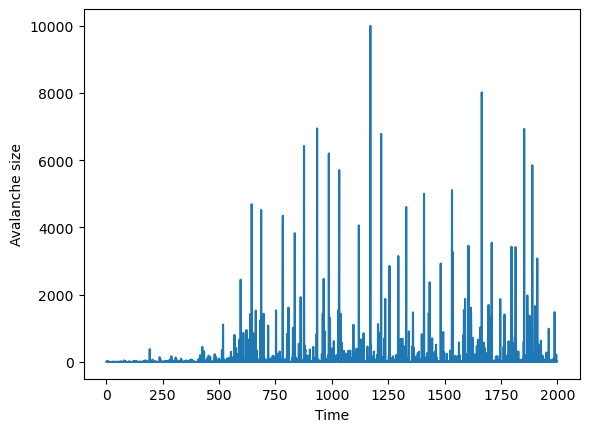

In [8]:
# 1
plt.plot(np.arange(len(soc)),soc)
plt.xlabel("Time")
plt.ylabel("Avalanche size")
plt.savefig("L=25_1.png")
plt.show()

Starting L= 25
Starting L= 50
Starting L= 100
Starting L= 200


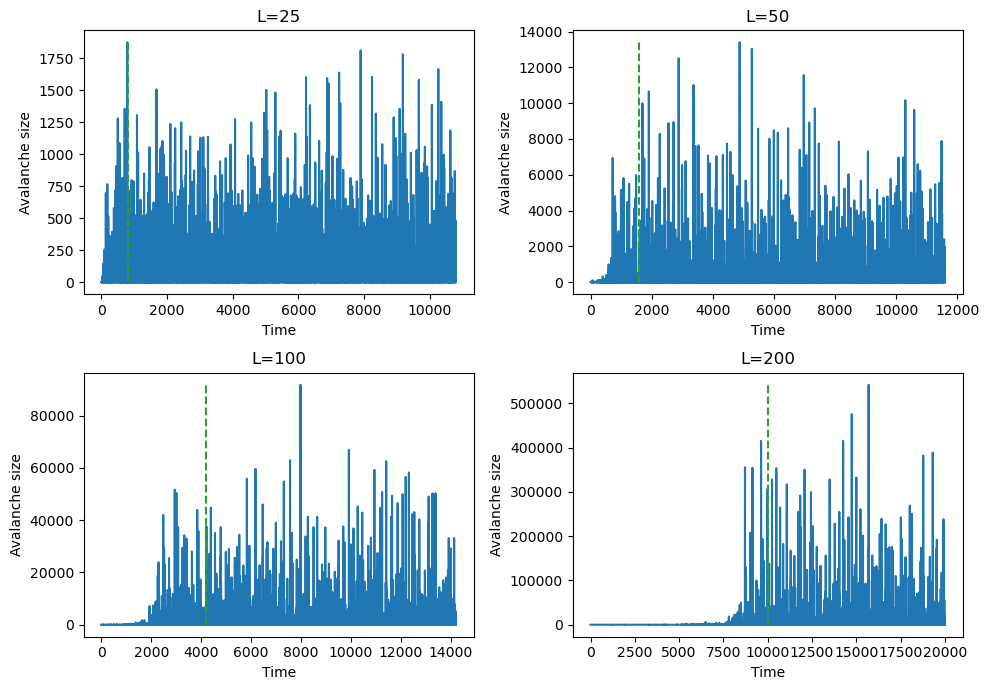

In [9]:
# 2

fig,ax = plt.subplots(2,2,figsize =(10,7))
for index,L in enumerate(L_list):
    print("Starting L=",L)
    data = sandpile(L=L,n_max=n_max[index])
    axis = ax.flatten()[index]
    axis.plot(np.arange(len(data)),data)
    axis.set_title("L="+str(L))
    axis.plot([n_min[index],n_min[index]],[0,max(data)],color="tab:green",linestyle="dashed")

    axis.set_xlabel("Time")
    axis.set_ylabel("Avalanche size")
    print(len(data))
    np.savetxt("Data\\sizes_L="+str(L)+".txt",data)
fig.tight_layout()
plt.show()

In [10]:
from scipy.optimize import curve_fit
def power_law(x,gamma,A):
    return A/x**gamma
def linear(x,gamma,A):
    return -gamma*x+np.log10(A)
def lin_plus_cut(x,gamma,A,C):
    return linear(x,gamma,A)-10**(x)/C
def power_cutoff(x,gamma,A,C):
    return A/x**gamma*np.exp(-x/C)

gamma_lin= 1.2796650532255671
gamma_lin= 1.25874335592095
gamma_lin= 1.237919009765459
gamma_lin= 1.2629990202205599


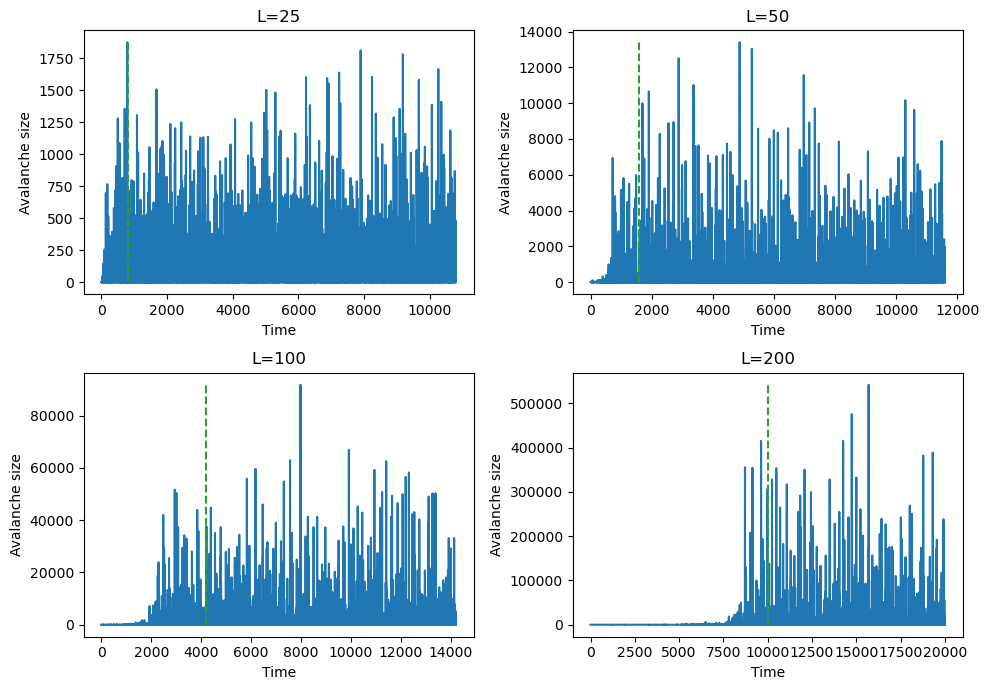

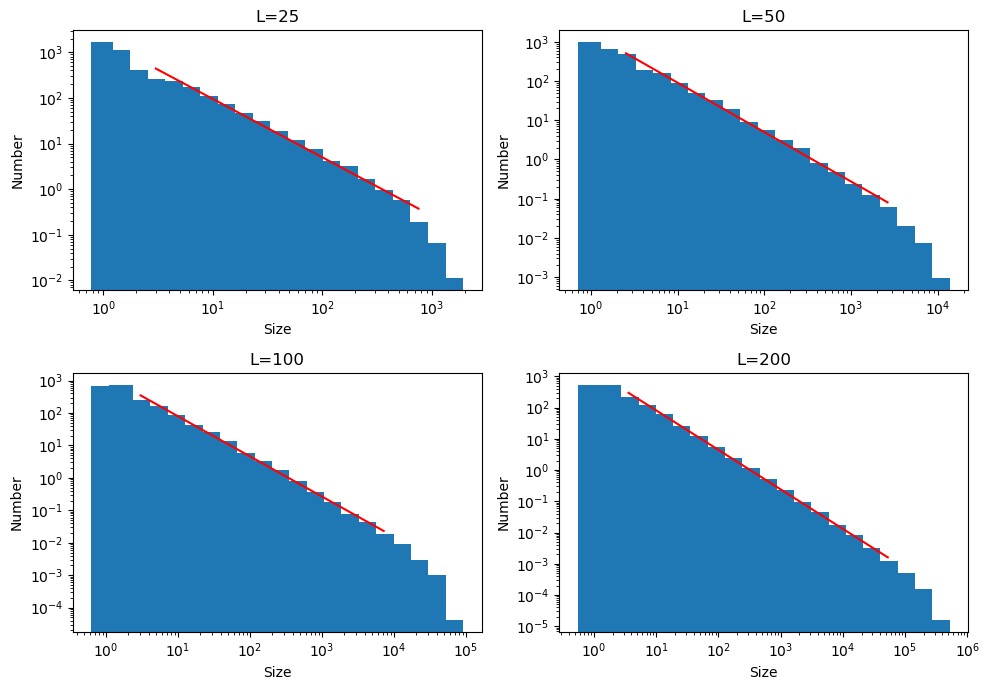

In [40]:
# plotting size destribution
fig_size,ax_size = plt.subplots(2,2,figsize =(10,7))
fig,ax = plt.subplots(2,2,figsize =(10,7))
#fig_test,ax_test = plt.subplots(2,2,figsize =(10,7))
s_cutoff_lower = [3,2,2,2]
s_cutoff_upper = [10**3,10**(3.5),10**4,10**5]
cutoff = []
gamma_list = []

for index,L in enumerate(L_list):
    axis_size = ax_size.flatten()[index]
    axis = ax.flatten()[index]
    #axis_test = ax_test.flatten()[index]
    data = np.genfromtxt("Data\\sizes_L="+str(L)+".txt")
    cutoff.append(max(data))            # perhaps change to maximum bin instead

    axis_size.plot(np.arange(len(data)),data)
    axis_size.set_title("L="+str(L))
    axis_size.plot([n_min[index],n_min[index]],[0,max(data)],color="tab:green",linestyle="dashed")

    axis_size.set_xlabel("Time")
    axis_size.set_ylabel("Avalanche size")   
    # cut out zero sizes

    data = data[n_min[index]:]
    data = data[data!=0]
    bins,hist = logbin_plot(data,ax=axis,bins=22)[:2]
    #cutoff.append(max(bins))            # changed to maximum bin value
    # cut small behavior
    bins_mask = np.logical_and(bins>s_cutoff_lower[index], bins<s_cutoff_upper[index])
    bins_cut = bins[bins_mask]
    hist_cut = hist[bins_mask]

    #cutoff_mask = bins <= L_cutoff_list[index]
    #bins_cut = bins[cutoff_mask]
    #hist_cut = hist[cutoff_mask]
    #print(min(bins_cut))

    lin_parms,lin_cov = curve_fit(linear,np.log10(bins_cut),np.log10(hist_cut))
    # parms_cutoff, cov_cutoff = curve_fit(lin_plus_cut, np.log10(bins),np.log10(hist))

    #X = np.linspace(min(bins),max(bins),1000)
    X = np.linspace(min(bins_cut),max(bins_cut),100)

    #axis_test.scatter(np.log10(bins),np.log10(hist))

    #YY = np.linspace(min(np.log10(bins)),max(np.log10(bins)),1000)
    
    #axis_test.plot(YY,lin_plus_cut(YY,*parms_cutoff))

    # axis.plot(X,power_cutoff(X,*parms_cutoff),color="green")
    axis.plot(X,power_law(X,*lin_parms),color="red")
    gamma_list.append(lin_parms[0])
    axis.set_xlabel("Size")
    axis.set_ylabel("Number")
    axis.set_title("L="+str(L))
    print("gamma_lin=",lin_parms[0])
    # print("D=",np.log(parms_cutoff[-1])/np.log(L))
fig_size.tight_layout()
fig.tight_layout()
plt.show()

C:\Users\Bruger\AppData\Local\Temp\ipykernel_13408\1564606073.py:5: RuntimeWarning: invalid value encountered in log10
  return -gamma*x+np.log10(A)


[-2.72969515  0.298978  ]


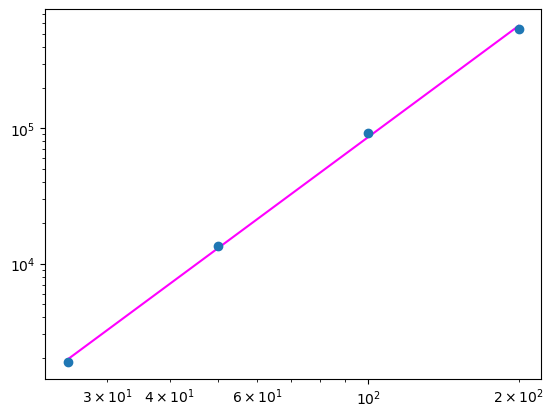

In [43]:
plt.scatter(L_list,cutoff)
plt.loglog()
P,C = curve_fit(linear,np.log10(L_list),np.log10(cutoff))
print(P)
X = np.linspace(min(L_list),max(L_list),100)
plt.plot(X,power_law(X,*P),color="magenta",zorder=0)
plt.show()


## for extracting avalanch dimension

In [81]:
N=200
soc,width = sandpile_size(N,n_max[3])

In [82]:
np.savetxt("size_and_width_200.txt",np.vstack((soc,width)).T,header="size,width")

In [32]:
data = np.loadtxt("size_and_width_200.txt")
soc = data[:,0]
width = data[:,1]
soc_no_zero = soc[n_min[3]:]
width_no_zero = width[n_min[3]:]

mask = soc_no_zero!=0

soc_no_zero = soc_no_zero[mask]
width_no_zero = width_no_zero[mask]

In [84]:
mask

array([ True,  True,  True, ..., False,  True, False])

C:\Users\Bruger\AppData\Local\Temp\ipykernel_24720\1564606073.py:5: RuntimeWarning: invalid value encountered in log10
  return -gamma*x+np.log10(A)


[-2.4805607   0.16200271]


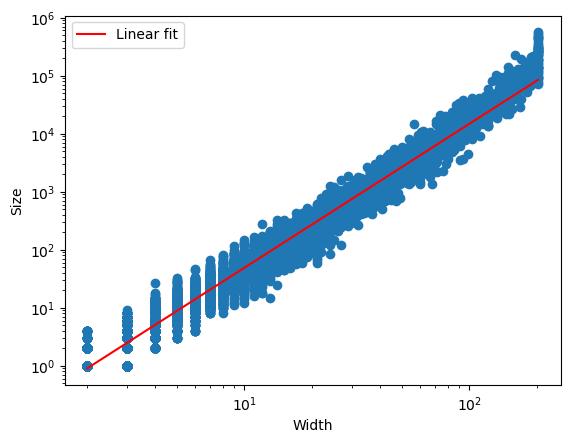

In [45]:
plt.scatter(width_no_zero,soc_no_zero)

p,c = curve_fit(linear,np.log10(width_no_zero),np.log10(soc_no_zero),p0=[2,1])
x = np.linspace(min(width_no_zero),max(width_no_zero),100)
plt.plot(x,power_law(x,*p),color="red",label="Linear fit")
# fig,ax = plt.Subplots(1,1)
# bins,hist,w = logbin_plot(soc)
print(p)
plt.loglog()
plt.xlabel("Width")
plt.ylabel("Size")
plt.legend()
plt.show()

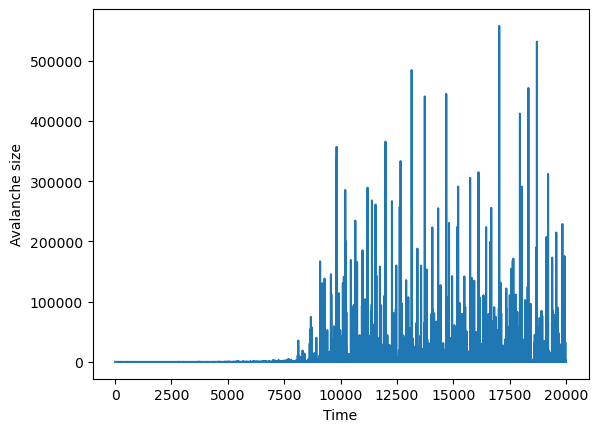

In [86]:
plt.plot(np.arange(len(soc)),soc)
plt.xlabel("Time")
plt.ylabel("Avalanche size")
plt.savefig("L=25_1.png")
plt.show()

## edge

In [8]:
N=200
soc = sandpile_edge(N,n_max[3]*10)

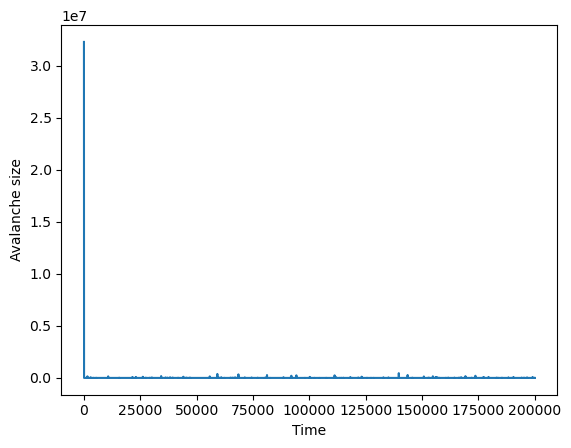

In [ ]:
np.savetxt("edge_driven_200_ones.txt",soc,header="size,width")
plt.plot(np.arange(len(soc))[2:],soc[2:])
plt.xlabel("Time")
plt.ylabel("Avalanche size")
plt.savefig("L=25_1.png")
plt.show()

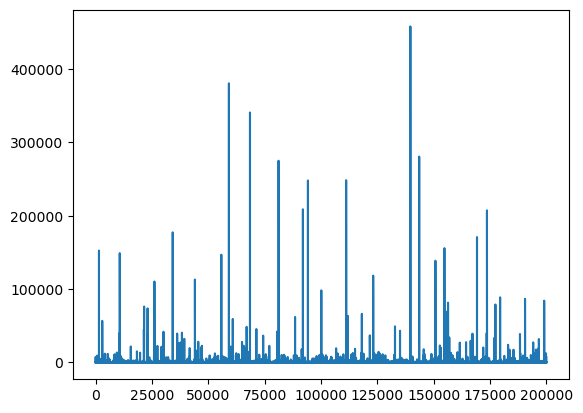

In [8]:
data = np.loadtxt("edge_driven_200_ones.txt")
fig_time,ax_time = plt.subplots(1,1)
ax_time.plot(np.arange(len(data))[2:],data[2:])
plt.show()

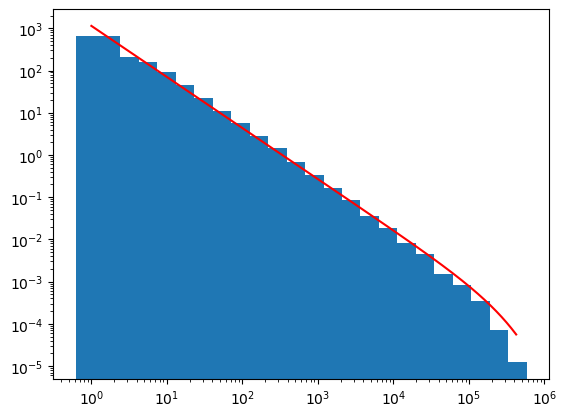

1.2091719248835908 2.414994458440191


In [21]:
data_cut = data[2:]
data_cut = data_cut[data_cut!=0]
fig_hist,ax_hist = plt.subplots(1,1)
bins,hist,widths = logbin_plot(data_cut,ax=ax_hist,bins=25)

parms,cov = curve_fit(lin_plus_cut,np.log10(bins),np.log10(hist))
X=np.linspace(min(bins),max(bins),1000)
ax_hist.plot(X,power_cutoff(X,*parms),color="red")
plt.show()
print(parms[0],np.log(parms[-1])/np.log(200))

## Testing zone

In [32]:
# slow but works with numba
@nb.njit
def topple(array,count):
     mask = np.copy(array)>1
     N = np.shape(array)[0]
     frustration = np.sum(mask)
     count += frustration
     # create new array with update values to be added to array
     update_array = np.zeros_like(array)
     # Make tuple of indecies of active sites
     mask_indecies = np.where(mask)
     # for each active site, generate two random neighbours to gift unit
     neighbour_index = np.floor(4*random.rand(frustration,2))
     neighbours = [[(i,(j+1)%N),(i,j-1),((i+1)%N,j),(i-1,j)] for i,j in zip(mask_indecies[0],mask_indecies[1])]
     
     for active_num in range(frustration):
          i,j = int(mask_indecies[0][active_num]),int(mask_indecies[1][active_num])
          update_array[i,j]+=-2
          
          update_array[neighbours[active_num][int(neighbour_index[active_num,0])]] += 1
          update_array[neighbours[active_num][int(neighbour_index[active_num,1])]] += 1

     array += update_array
     array[:,0] = 0
     array[:,-1] = 0
     array[0,:] = 0
     array[-1,:] = 0
     return count

In [34]:
grid = np.zeros((7,7))
grid[2,2]=2
grid[3,3]=2
print(grid)
topple(grid,0)
print(grid)


[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 2. 0. 0. 0. 0.]
 [0. 0. 0. 2. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]
[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]


In [193]:
grid = np.zeros((7,7))
grid[2,2]=2
grid[3,3]=2
print(grid)
i,j=topple_size(grid,0,np.full((7,7),False))
print(grid)
print(j)
print(clean_array(j))

[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 2. 0. 0. 0. 0.]
 [0. 0. 0. 2. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]
[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 2. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]
[[False False False False False False False]
 [False False False False False False False]
 [False False  True  True False False False]
 [False False  True  True  True False False]
 [False False False False False False False]
 [False False False False False False False]
 [False False False False False False False]]
[[ True  True False]
 [ True  True  True]]


[[1 2 3 4]
 [5 6 7 8]] [ True  True]
[[1 2 3 4]
 [5 6 7 8]] [[False False False  True]
 [ True  True  True  True]]
True


array([[1, 2, 3, 4],
       [5, 6, 7, 8]])